In [1]:
conda activate xregrid_env

usage: conda [-h] [-v] [--no-plugins] [-V] COMMAND ...
conda: error: argument COMMAND: invalid choice: 'activate' (choose from 'clean', 'compare', 'config', 'create', 'info', 'init', 'install', 'list', 'notices', 'package', 'remove', 'uninstall', 'rename', 'run', 'search', 'update', 'upgrade', 'doctor', 'repoquery', 'env')

Note: you may need to restart the kernel to use updated packages.


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xarray as xr
from matplotlib.colors import Normalize
from xregrid import Regridder

In [3]:
file = "/glade/campaign/acom/acom-weather/emmons/ASIAAQ_sims/f.e3b06m.FCnudged.t6s.GEMSne30x8.01/atm/hist/f.e3b06m.FCnudged.t6s.GEMSne30x8.01.cam.h1a.2024-03-14-00000.nc"
scrip_file = "/glade/work/emmons/VRM_Files/ne0np4.GEMS01.ne30x8/grids/GEMS01_ne30x8_np4_SCRIP.nc"
mesh_file = "/glade/work/emmons/VRM_Files/ne0np4.GEMS01.ne30x8/grids/GEMS01_ne30x8_np4_MESH.nc"
ds = xr.open_dataset(file)
scrip_ds = xr.open_dataset(scrip_file)
mesh_ds = xr.open_dataset(mesh_file)


In [4]:
xr.open_dataset("/glade/work/emmons/VRM_Files/ne0np4.GEMS01.ne30x8/grids/GEMS01_ne30x8_np4_MESH.nc")

<xarray.Dataset> Size: 38MB
Dimensions:         (nodeCount: 414300, coordDim: 2, elementCount: 248582,
                     maxNodePElement: 12)
Dimensions without coordinates: nodeCount, coordDim, elementCount,
                                maxNodePElement
Data variables:
    nodeCoords      (nodeCount, coordDim) float64 7MB ...
    elementConn     (elementCount, maxNodePElement) float64 24MB ...
    numElementConn  (elementCount) int32 994kB ...
    centerCoords    (elementCount, coordDim) float64 4MB ...
    elementArea     (elementCount) float64 2MB ...
    elementMask     (elementCount) int32 994kB ...
Attributes:
    gridType:       unstructured mesh
    version:        0.9
    inputFile:      /glade/work/emmons/VRM_Files//ne0np4.GEMS01.ne30x8/grids/...
    timeGenerated:  Tue Jul  2 17:21:12 2024

In [5]:
scrip_ds

<xarray.Dataset> Size: 57MB
Dimensions:          (grid_rank: 1, grid_size: 248582, grid_corners: 12)
Dimensions without coordinates: grid_rank, grid_size, grid_corners
Data variables:
    grid_dims        (grid_rank) int32 4B ...
    grid_imask       (grid_size) int32 994kB ...
    grid_area        (grid_size) float64 2MB ...
    grid_center_lat  (grid_size) float64 2MB ...
    grid_center_lon  (grid_size) float64 2MB ...
    grid_corner_lat  (grid_size, grid_corners) float64 24MB ...
    grid_corner_lon  (grid_size, grid_corners) float64 24MB ...
    rrfac            (grid_size) float64 2MB ...
Attributes:
    Grid:        Variable Resolution: GEMS01_ne30x8_EXODUS.nc
    Created by:  Gen_ControlVolumes.exe

In [8]:
"""import numpy as np
import xarray as xr

# -----------------------------
# 1️⃣ SCRIP polygon 顶点
# lon_b, lat_b shape = (grid_size, nCorners)
lon_b = scrip_ds['grid_corner_lon'].values  # degrees
lat_b = scrip_ds['grid_corner_lat'].values
lon_c = scrip_ds['grid_center_lon'].values  # degrees
lat_c = scrip_ds['grid_center_lat'].values

# unwrap polygon
def unwrap_cell(lon):
    lon = lon.copy()
    ref = lon[0]

    for i in range(1, len(lon)):
        diff = lon[i] - ref

        if diff > 180:
            lon[i] -= 360
        elif diff < -180:
            lon[i] += 360

    return lon

lon_b_unwrapped = np.array([unwrap_cell(lon_b[i]) for i in range(lon_b.shape[0])])

# -----------------------------
# 2️⃣ 构建唯一 vertex 并映射
# -----------------------------
grid_size, nCorners = lon_b.shape

# flatten 所有角点
all_vertices = np.column_stack([lat_b.flatten(), lon_b_unwrapped.flatten()])

# 找唯一顶点，并返回 inverse_idx
unique_vertices, inverse_idx = np.unique(all_vertices, axis=0, return_inverse=True)
latVertex = unique_vertices[:,0]
lonVertex = unique_vertices[:,1]
nVertices = len(latVertex)

# verticesOnCell: 重新映射
verticesOnCell = inverse_idx.reshape(grid_size, nCorners) + 1  # 1-based
# 去掉重复角点
nEdgesOnCell = np.array([len(np.unique(verticesOnCell[i])) for i in range(grid_size)])
maxNodes = nEdgesOnCell.max()

# 填充 verticesOnCell 到 maxNodes
verticesOnCell_padded = np.full((grid_size, maxNodes), -1, dtype=int)
for i in range(grid_size):
    unique_idx = np.unique(verticesOnCell[i])
    verticesOnCell_padded[i, :len(unique_idx)] = unique_idx

# -----------------------------
# 3️⃣ cell center
# -----------------------------
latCell = lat_c
lonCell = np.array(unwrap_cell(lon_c))"""

# -----------------------------
# 1️⃣ 构建 data_vars
# -----------------------------
data_vars = {}

for varname in ds.data_vars:
    var = ds[varname]
    dims = var.dims

    data_vars[varname] = (dims, var.values)


# -----------------------------
# 2️⃣ 构建 coords
# -----------------------------
coords = {
    "time": ds["time"],
    "lev": ds["lev"],

    "latCell": (
        ["ncol"],
        np.deg2rad(mesh_ds.centerCoords[:,1].values),
        {"units": "radians"}
    ),

    "lonCell": (
        ["ncol"],
        np.deg2rad(mesh_ds.centerCoords[:,0].values),
        {"units": "radians"}
    ),

    "latVertex": (
        ["nVertices"],
        np.deg2rad(mesh_ds.nodeCoords[:,1].values),
        {"units": "radians"}
    ),

    "lonVertex": (
        ["nVertices"],
        np.deg2rad(mesh_ds.nodeCoords[:,0].values),
        {"units": "radians"}
    ),

    "verticesOnCell": (
        ["ncol", "maxNodes"],
        mesh_ds.elementConn.values
    ),

    "nEdgesOnCell": (
        ["ncol"],
        mesh_ds.numElementConn.values.astype(int)
    ),
}


# -----------------------------
# 3️⃣ 构建 Dataset
# -----------------------------
ds_mpas_like = xr.Dataset(
    data_vars=data_vars,
    coords=coords
)

In [9]:
ds_mpas_like

<xarray.Dataset> Size: 929MB
Dimensions:         (ncol: 248582, lev: 32, ilev: 33, time: 1, nbnd: 2,
                     nVertices: 414300, maxNodes: 12)
Coordinates:
    latCell         (ncol) float64 2MB -0.5288 -0.5376 -0.5517 ... 0.614 0.612
    lonCell         (ncol) float64 2MB 6.228 6.24 6.259 ... 2.532 2.538 2.535
    nEdgesOnCell    (ncol) int64 2MB 8 6 6 6 6 4 4 6 6 4 ... 4 4 4 4 6 6 4 4 4 4
  * lev             (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * time            (time) datetime64[ns] 8B 2024-03-13T12:00:00
    latVertex       (nVertices) float64 3MB -0.5354 -0.5314 ... 0.616 0.614
    lonVertex       (nVertices) float64 3MB 6.231 6.232 6.236 ... 2.532 2.535
    verticesOnCell  (ncol, maxNodes) float64 24MB 1.0 2.0 3.0 ... nan nan nan
Dimensions without coordinates: ncol, ilev, nbnd, nVertices, maxNodes
Data variables: (12/71)
    lat             (ncol) float64 2MB -30.3 -30.8 -31.61 ... 35.18 35.18 35.06
    lon             (ncol) float64 2MB 356.9 357.5 358.6 ... 145.1 145.4 145.2
    areawt          (ncol) float64 2MB 4.587e-06 1.156e-05 ... 6.196e-07
    area            (ncol) float64 2MB 5.764e-05 0.0001452 ... 7.786e-06
    hyam            (lev) float64 256B 0.003643 0.007595 ... 0.001989 0.0
    hybm            (lev) float64 256B 0.0 0.0 0.0 0.0 ... 0.9512 0.9743 0.9926
    ...              ...
    dst_tot         (time, lev, ncol) float32 32MB 7.253e-13 ... 6.109e-10
    ncl_tot         (time, lev, ncol) float32 32MB 2.008e-13 ... 1.735e-08
    pom_tot         (time, lev, ncol) float32 32MB 1.173e-12 ... 1.539e-10
    so4_tot         (time, lev, ncol) float32 32MB 2.676e-11 ... 4.474e-10
    soa_tot         (time, lev, ncol) float32 32MB 4.228e-23 ... 1.984e-10
    PM25            (time, lev, ncol) float32 32MB 1.617e-13 ... 1.853e-08

In [10]:
from xregrid import Regridder, create_global_grid

# 2. Define a rectilinear target grid (e.g., .1° global)
target_grid = create_global_grid(.1, .1)

# 3. Create the regridder using the 'conservative' method
# XRegrid will detect the MPAS connectivity and use ESMF Mesh
regridder = Regridder(ds_mpas_like, target_grid, method="conservative", periodic=True)

# 4. Apply regridding
regridded = regridder(ds_mpas_like.NO2)
regridded

<xarray.DataArray 'NO2' (time: 1, lev: 32, lat: 1800, lon: 3600)> Size: 829MB
array([[[[4.8636273e-09, 4.8636273e-09, 4.8636273e-09, ...,
          4.8636273e-09, 4.8636273e-09, 4.8636273e-09],
         [4.8636273e-09, 4.8636273e-09, 4.8636273e-09, ...,
          4.8636273e-09, 4.8636273e-09, 4.8636273e-09],
         [4.8636273e-09, 4.8636273e-09, 4.8636273e-09, ...,
          4.8636273e-09, 4.8636273e-09, 4.8636273e-09],
         ...,
         [6.0614469e-09, 6.0614469e-09, 6.0614469e-09, ...,
          6.0614469e-09, 6.0614469e-09, 6.0614469e-09],
         [6.1288650e-09, 6.1287282e-09, 6.1285923e-09, ...,
          6.1292806e-09, 6.1291412e-09, 6.1290026e-09],
         [6.1331966e-09, 6.1331966e-09, 6.1331966e-09, ...,
          6.1331966e-09, 6.1331966e-09, 6.1331966e-09]],

        [[5.8287055e-09, 5.8287055e-09, 5.8287055e-09, ...,
          5.8287055e-09, 5.8287055e-09, 5.8287055e-09],
         [5.8287055e-09, 5.8287055e-09, 5.8287055e-09, ...,
          5.8287055e-09, 5.8287055e-09, 5.8287055e-09],
         [5.8287055e-09, 5.8287055e-09, 5.8287055e-09, ...,
          5.8287055e-09, 5.8287055e-09, 5.8287055e-09],
...
          6.7718942e-12, 6.7718942e-12, 6.7718942e-12],
         [6.8289354e-12, 6.8288201e-12, 6.8287047e-12, ...,
          6.8292871e-12, 6.8291692e-12, 6.8290521e-12],
         [6.8326005e-12, 6.8326005e-12, 6.8326005e-12, ...,
          6.8326005e-12, 6.8326005e-12, 6.8326005e-12]],

        [[5.8386092e-13, 5.8386092e-13, 5.8386092e-13, ...,
          5.8386092e-13, 5.8386092e-13, 5.8386092e-13],
         [5.8386092e-13, 5.8386092e-13, 5.8386092e-13, ...,
          5.8386092e-13, 5.8386092e-13, 5.8386092e-13],
         [5.8386092e-13, 5.8386092e-13, 5.8386092e-13, ...,
          5.8386092e-13, 5.8386092e-13, 5.8386092e-13],
         ...,
         [6.8647111e-12, 6.8647111e-12, 6.8647111e-12, ...,
          6.8647111e-12, 6.8647111e-12, 6.8647111e-12],
         [6.8807889e-12, 6.8807564e-12, 6.8807239e-12, ...,
          6.8808882e-12, 6.8808548e-12, 6.8808219e-12],
         [6.8818219e-12, 6.8818219e-12, 6.8818219e-12, ...,
          6.8818219e-12, 6.8818219e-12, 6.8818219e-12]]]],
      shape=(1, 32, 1800, 3600), dtype=float32)
Coordinates:
  * time          (time) datetime64[ns] 8B 2024-03-13T12:00:00
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * lat           (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon           (lon) float64 29kB 0.05 0.15 0.25 0.35 ... 359.8 359.9 360.0
    nEdgesOnCell  (lat, lon) int64 52MB 6 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6 6
    lonCell       (lat, lon) float64 52MB 0.1396 0.1396 0.1396 ... 3.281 3.281
    latCell       (lat, lon) float64 52MB -1.565 -1.565 -1.565 ... 1.565 1.565
Attributes:
    crs:      GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble"...
    history:  2026-03-05 16:19:56: Regridded using xregrid.Regridder (ESMF/es...

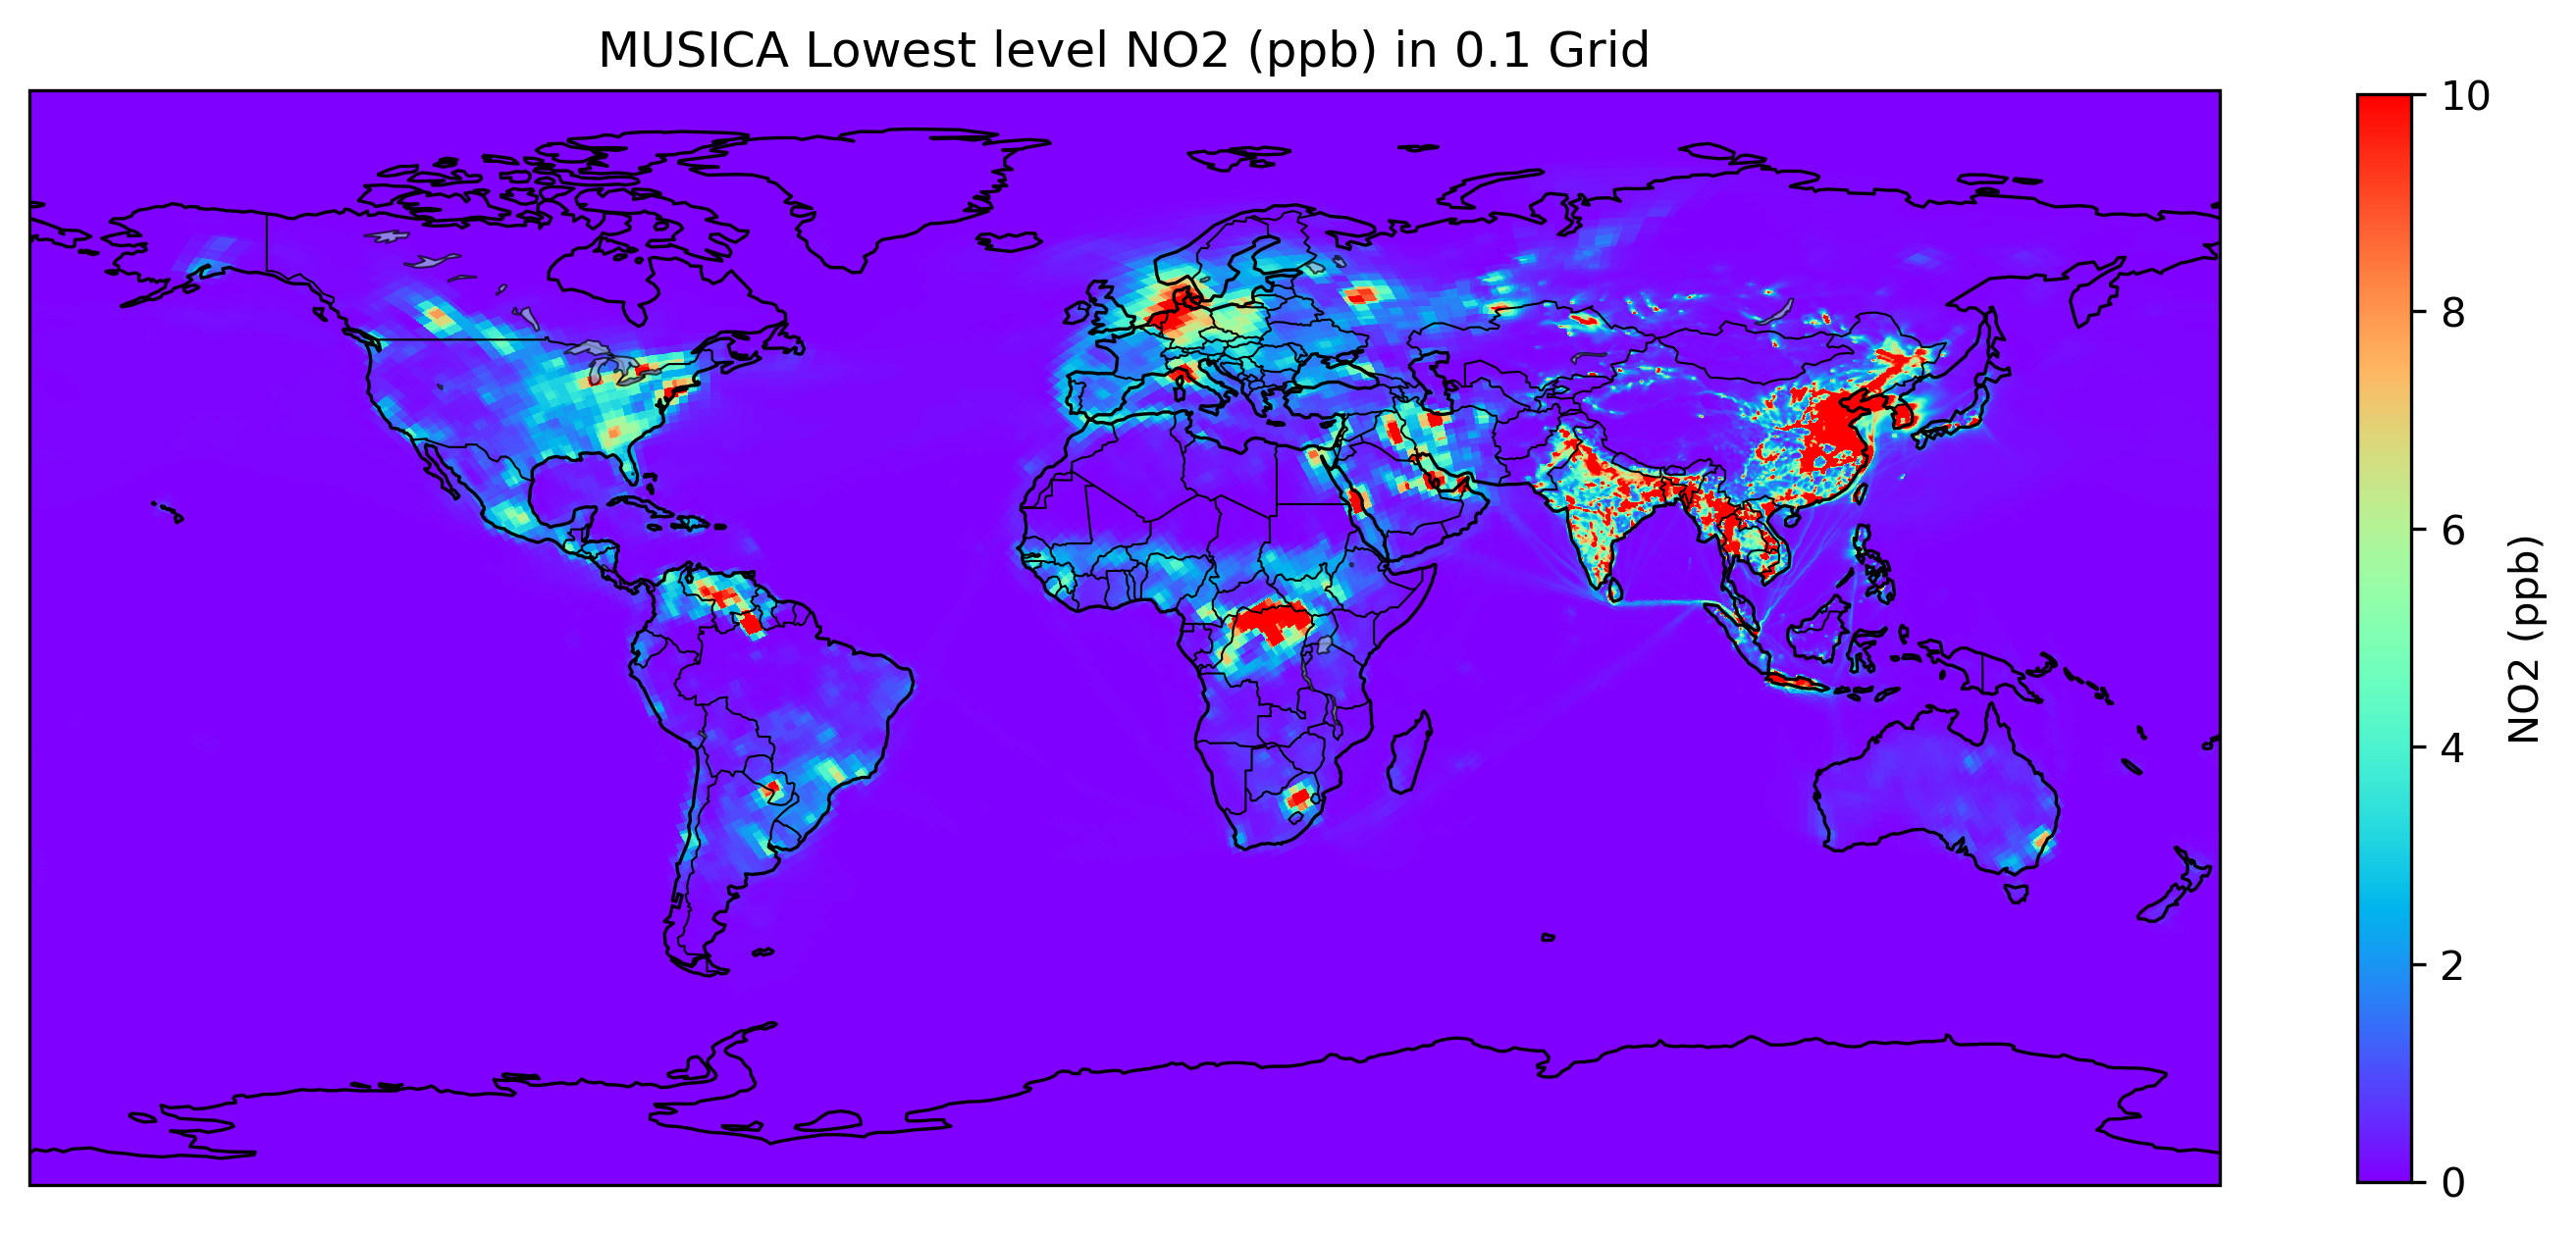

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
import numpy as np

# -----------------------------
# 1️⃣ 提取最低层 NO2
# -----------------------------
data = regridded.isel(time=0, lev=-1).values * 1e9  # 转成 ppb
lat = regridded['lat'].values
lon = regridded['lon'].values

# -----------------------------
# 2️⃣ 绘图
# -----------------------------
fig, ax = plt.subplots(figsize=(12,8),dpi=300, subplot_kw={'projection': ccrs.PlateCarree()})

# 背景
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, linewidth=0.5, alpha=0.7, edgecolor='black')

# 设置颜色归一化
norm = Normalize(vmin=0, vmax=10)

# pcolormesh 绘制
# 注意 lat/lon 的 shape 要对应 data.shape
mesh = ax.pcolormesh(lon, lat, data, cmap='rainbow', norm=norm, shading='auto', transform=ccrs.PlateCarree())

# 全局显示
ax.set_global()
ax.set_title('MUSICA Lowest level NO2 (ppb) in 0.1 Grid')

# colorbar
plt.colorbar(mesh, ax=ax, shrink=0.6, label='NO2 (ppb)')

plt.show()

In [12]:
from xregrid import Regridder, create_global_grid

# 2. Define a rectilinear target grid (e.g., 5° global)
target_grid = create_global_grid(.1, .1)

# 3. Create the regridder
# XRegrid will detect the MPAS connectivity and use ESMF Mesh
regridder_N = Regridder(ds_mpas_like, 
                         target_grid, 
                         method="nearest_s2d", 
                         periodic=True)

# 4. Apply regridding
regridded_N = regridder_N(ds_mpas_like.NO2)
regridded_N

<xarray.DataArray 'NO2' (time: 1, lev: 32, lat: 1800, lon: 3600)> Size: 829MB
array([[[[4.8636273e-09, 4.8636273e-09, 4.8636273e-09, ...,
          4.8636273e-09, 4.8636273e-09, 4.8636273e-09],
         [4.8636273e-09, 4.8636273e-09, 4.8636273e-09, ...,
          4.8636273e-09, 4.8636273e-09, 4.8636273e-09],
         [4.8636273e-09, 4.8636273e-09, 4.8636273e-09, ...,
          4.8636273e-09, 4.8636273e-09, 4.8636273e-09],
         ...,
         [6.0614469e-09, 6.0614469e-09, 6.0614469e-09, ...,
          6.0614469e-09, 6.0614469e-09, 6.0614469e-09],
         [6.0614469e-09, 6.0614469e-09, 6.0614469e-09, ...,
          6.0614469e-09, 6.0614469e-09, 6.0614469e-09],
         [6.0614469e-09, 6.0614469e-09, 6.0614469e-09, ...,
          6.0614469e-09, 6.0614469e-09, 6.0614469e-09]],

        [[5.8287055e-09, 5.8287055e-09, 5.8287055e-09, ...,
          5.8287055e-09, 5.8287055e-09, 5.8287055e-09],
         [5.8287055e-09, 5.8287055e-09, 5.8287055e-09, ...,
          5.8287055e-09, 5.8287055e-09, 5.8287055e-09],
         [5.8287055e-09, 5.8287055e-09, 5.8287055e-09, ...,
          5.8287055e-09, 5.8287055e-09, 5.8287055e-09],
...
          6.7718942e-12, 6.7718942e-12, 6.7718942e-12],
         [6.7718942e-12, 6.7718942e-12, 6.7718942e-12, ...,
          6.7718942e-12, 6.7718942e-12, 6.7718942e-12],
         [6.7718942e-12, 6.7718942e-12, 6.7718942e-12, ...,
          6.7718942e-12, 6.7718942e-12, 6.7718942e-12]],

        [[5.8386092e-13, 5.8386092e-13, 5.8386092e-13, ...,
          5.8386092e-13, 5.8386092e-13, 5.8386092e-13],
         [5.8386092e-13, 5.8386092e-13, 5.8386092e-13, ...,
          5.8386092e-13, 5.8386092e-13, 5.8386092e-13],
         [5.8386092e-13, 5.8386092e-13, 5.8386092e-13, ...,
          5.8386092e-13, 5.8386092e-13, 5.8386092e-13],
         ...,
         [6.8647111e-12, 6.8647111e-12, 6.8647111e-12, ...,
          6.8647111e-12, 6.8647111e-12, 6.8647111e-12],
         [6.8647111e-12, 6.8647111e-12, 6.8647111e-12, ...,
          6.8647111e-12, 6.8647111e-12, 6.8647111e-12],
         [6.8647111e-12, 6.8647111e-12, 6.8647111e-12, ...,
          6.8647111e-12, 6.8647111e-12, 6.8647111e-12]]]],
      shape=(1, 32, 1800, 3600), dtype=float32)
Coordinates:
  * time          (time) datetime64[ns] 8B 2024-03-13T12:00:00
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * lat           (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon           (lon) float64 29kB 0.05 0.15 0.25 0.35 ... 359.8 359.9 360.0
    nEdgesOnCell  (lat, lon) int64 52MB 6 6 6 6 6 6 6 6 6 ... 8 8 8 8 8 8 8 8 8
    lonCell       (lat, lon) float64 52MB 0.1396 0.1396 0.1396 ... 0.1396 0.1396
    latCell       (lat, lon) float64 52MB -1.565 -1.565 -1.565 ... 1.564 1.564
Attributes:
    crs:      GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble"...
    history:  2026-03-05 16:35:40: Regridded using xregrid.Regridder (ESMF/es...

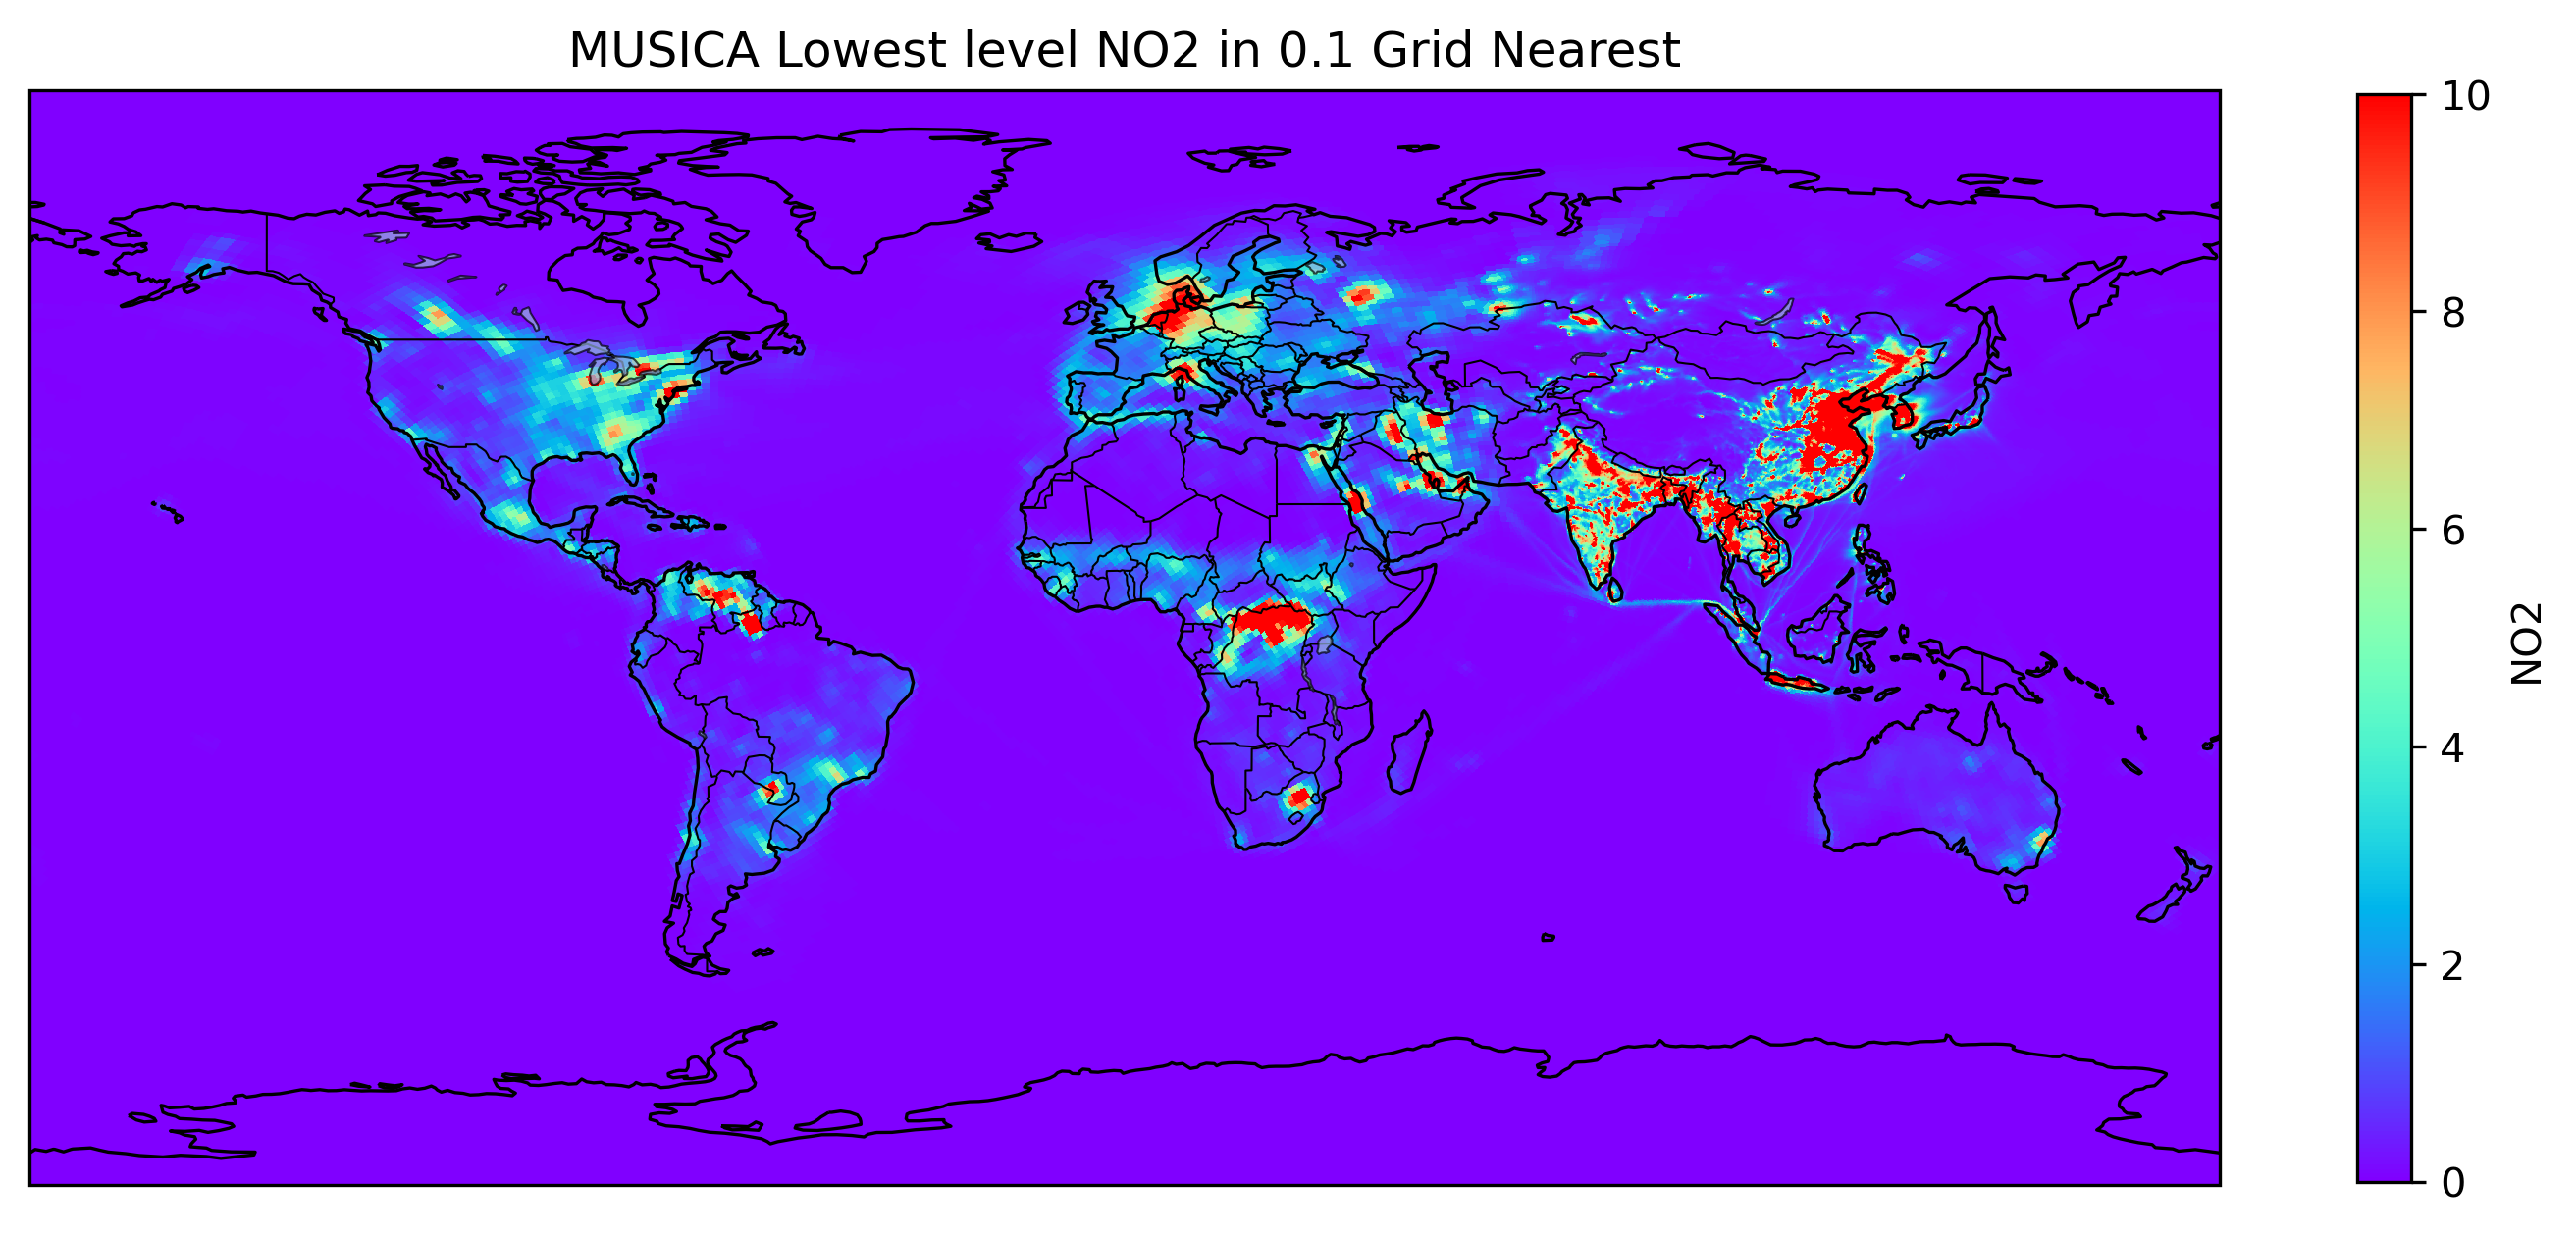

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
import numpy as np

# -----------------------------
# 1️⃣ 提取最低层 NO2
# -----------------------------
data = regridded_N.isel(time=0, lev=-1).values * 1e9 
lat = regridded_N['lat'].values
lon = regridded_N['lon'].values

# -----------------------------
# 2️⃣ 绘图
# -----------------------------
fig, ax = plt.subplots(figsize=(12,8),dpi=300, subplot_kw={'projection': ccrs.PlateCarree()})

# 背景
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, linewidth=0.5, alpha=0.7, edgecolor='black')

# 设置颜色归一化
norm = Normalize(vmin=0, vmax=10)

# pcolormesh 绘制
# 注意 lat/lon 的 shape 要对应 data.shape
mesh = ax.pcolormesh(lon, lat, data, cmap='rainbow', norm=norm, shading='auto', transform=ccrs.PlateCarree())

# 全局显示
ax.set_global()
ax.set_title('MUSICA Lowest level NO2 in 0.1 Grid Nearest')

# colorbar
plt.colorbar(mesh, ax=ax, shrink=0.6, label='NO2')

plt.show()